### Data Imports

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# time series data
df_dur = pd.read_csv("../data/duration.csv")
df_ep = pd.read_csv("../data/e_price.csv")
df_occ = pd.read_csv("../data/occupancy.csv")
df_sp = pd.read_csv("../data/s_price.csv")
df_vol = pd.read_csv("../data/volume.csv")
# info + weather
inf  = pd.read_csv("../data/inf.csv")
w_airport = pd.read_csv("../data/weather_airport.csv")
w_central = pd.read_csv("../data/weather_central.csv")

### Data Pre-Processing

In [3]:
w_airport.rename(columns={w_airport.columns[0]: 'time'}, inplace=True)
w_central.rename(columns={w_central.columns[0]: 'time'}, inplace=True)

In [4]:
w_airport['time'] = pd.to_datetime(w_airport['time'])
w_central['time'] = pd.to_datetime(w_central['time'])

C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\1842167773.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  w_airport['time'] = pd.to_datetime(w_airport['time'])
C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\1842167773.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  w_central['time'] = pd.to_datetime(w_central['time'])


In [5]:
w_airport = w_airport[::-1].reset_index(drop=True)
w_central = w_central[::-1].reset_index(drop=True)

In [6]:
w_airport = w_airport[(w_airport["time"] >= '2022-09-01') & (w_airport["time"] < '2023-03-01')] 
w_central = w_central[(w_central["time"] >= '2022-09-01') & (w_central["time"] < '2023-03-01')] 

In [7]:
w_airport = w_airport.set_index('time')

In [8]:
full_range = pd.date_range(
    start=w_airport.index.min(),
    end=w_airport.index.max(),
    freq='h'
)

In [9]:
missing = full_range.difference(w_airport.index)
print(missing)

DatetimeIndex(['2022-12-17 07:00:00', '2023-01-17 20:00:00'], dtype='datetime64[ns]', freq=None)


In [10]:
w_airport = w_airport.reindex(full_range).ffill()
w_airport = w_airport.rename_axis('time').reset_index()

In [11]:
inf['station_id'] = inf['station_id'].astype(str)
cap = inf.set_index('station_id')['pile_count'] 

occ_rate = df_occ.copy()
for station in occ_rate.columns:
    if station in cap.index:
        occ_rate[station] = occ_rate[station] / cap[station]
occ_rate.head()

,time,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,2673,2674,2675,2676,2677,2678,2679,2680,2681,2682
0,2022-09-01 00:00:00,0.20,0.409091,0.333333,0.909091,0.454545,0.4,0.0,0.454545,0.500000,...,0.444444,0.25,0.4,0.555556,0.500000,0.0,0.333333,0.166667,0.2,0.0
1,2022-09-01 01:00:00,0.35,0.272727,0.333333,0.545455,0.454545,0.7,0.0,0.431818,0.652778,...,0.694444,0.50,1.0,0.666667,0.583333,0.0,0.250000,0.250000,0.3,0.0
2,2022-09-01 02:00:00,0.35,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.833333,...,0.472222,0.25,0.0,0.555556,0.666667,0.0,0.583333,0.250000,0.1,0.0
3,2022-09-01 03:00:00,0.40,0.136364,0.166667,0.909091,0.454545,0.8,0.0,0.454545,0.805556,...,0.472222,0.25,1.0,0.555556,0.666667,0.0,0.583333,0.250000,0.1,0.0
4,2022-09-01 04:00:00,0.30,0.272727,0.333333,0.727273,0.454545,0.7,0.0,0.431818,0.750000,...,0.694444,0.50,1.0,0.555556,0.583333,0.0,0.250000,0.250000,0.2,0.0


In [12]:
def parse_wind_direction(dd_series):
    """Convert text wind direction to sine/cosine of bearing degrees."""
    direction_map = {
        'north':            0,
        'north-northeast':  22.5,
        'northeast':        45,
        'east-northeast':   67.5,
        'east':             90,
        'east-southeast':   112.5,
        'southeast':        135,
        'south-southeast':  157.5,
        'south':            180,
        'south-southwest':  202.5,
        'southwest':        225,
        'west-southwest':   247.5,
        'west':             270,
        'west-northwest':   292.5,
        'northwest':        315,
        'north-northwest':  337.5,
        'calm':             0,  # no wind
    }
    def extract_bearing(text):
        if pd.isna(text):
            return np.nan
        text = text.lower()
        # strip "wind blowing from the " prefix
        text = re.sub(r'wind blowing from the\s*', '', text).strip()
        return direction_map.get(text, np.nan)

    bearings = dd_series.apply(extract_bearing)
    rad = np.deg2rad(bearings)
    return np.sin(rad), np.cos(rad)


def parse_rain(ww_series):
    """Binary: 1 if any rain/shower/drizzle mentioned."""
    rain_keywords = ['rain', 'shower', 'drizzle', 'thunderstorm', 'precipitation']
    def is_rain(text):
        if pd.isna(text):
            return 0
        return int(any(kw in str(text).lower() for kw in rain_keywords))
    return ww_series.apply(is_rain)


def parse_cloud_cover(c_series):
    """Map cloud description to ordinal 0–4 scale."""
    def cloud_ordinal(text):
        if pd.isna(text):
            return np.nan
        text = str(text).lower()
        if 'no significant' in text or 'clear' in text:
            return 0
        elif 'few' in text:          # 10–30%
            return 1
        elif 'scattered' in text:    # 40–50%
            return 2
        elif 'broken' in text:       # 60–90%
            return 3
        elif 'overcast' in text:     # 100%
            return 4
        return np.nan
    return c_series.apply(cloud_ordinal)


def parse_visibility(vv_series):
    """Convert visibility to numeric km; '10.0 and more' → 10.0."""
    def to_numeric(text):
        if pd.isna(text):
            return np.nan
        text = str(text).lower().replace('and more', '').strip()
        try:
            return float(text)
        except ValueError:
            return np.nan
    return vv_series.apply(to_numeric)


def preprocess_weather(df, prefix):
    out = pd.DataFrame(index=df.index)

    def safe_col(name):
        return df[name] if name in df.columns else pd.Series(index=df.index)
        
    out['T']  = pd.to_numeric(df['T'],  errors='coerce')
    out['P']  = pd.to_numeric(df['P'],  errors='coerce')
    out['U']  = pd.to_numeric(df['U'],  errors='coerce')
    out['Ff'] = pd.to_numeric(df['Ff'], errors='coerce')
    out['Td'] = pd.to_numeric(df['Td'], errors='coerce')

    out['wind_sin'], out['wind_cos'] = parse_wind_direction(df['DD'])
    out['is_raining']  = parse_rain(df['WW'])
    out['cloud_cover'] = parse_cloud_cover(safe_col('c'))
    out['visibility']  = parse_visibility(df['VV'])

    out.columns = [f'{prefix}_{c}' for c in out.columns]
    return out

def load_weather(df, prefix):
    df.index = pd.to_datetime(df['time'], format='%d.%m.%Y %H:%M')
    df = df.drop(columns=['time'])
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    num_cols = ['T', 'P', 'U', 'Ff', 'Td']
    cat_cols = ['DD', 'WW', 'c', 'VV']

    num_cols = [col for col in num_cols if col in df.columns]
    cat_cols = [col for col in cat_cols if col in df.columns]
    
    df_num = df[num_cols].apply(pd.to_numeric, errors='coerce').resample('h').mean()
    df_cat = df[cat_cols].resample('h').first()

    df = pd.concat([df_num, df_cat], axis=1)

    return preprocess_weather(df, prefix)

w_airport = load_weather(w_airport, 'ap')
w_central = load_weather(w_central, 'ct')

weather = pd.concat([w_airport, w_central], axis=1)

In [13]:
weather = weather.reset_index()
weather

,time,ap_T,ap_P,ap_U,ap_Ff,ap_Td,ap_wind_sin,ap_wind_cos,ap_is_raining,ap_cloud_cover,...,ct_T,ct_P,ct_U,ct_Ff,ct_Td,ct_wind_sin,ct_wind_cos,ct_is_raining,ct_cloud_cover,ct_visibility
0,2022-09-01 00:00:00,28.0,756.2,89.0,2.0,26.0,0.000000e+00,1.000000,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-09-01 01:00:00,29.0,756.2,84.0,1.0,26.0,NaN,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-09-01 02:00:00,29.0,755.4,79.0,4.0,25.0,NaN,NaN,0,2,...,27.3,756.1,87.0,1.0,24.9,-0.382683,9.238795e-01,0.0,NaN,27.0
3,2022-09-01 03:00:00,29.0,755.4,79.0,3.0,25.0,3.826834e-01,0.923880,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4,2022-09-01 04:00:00,28.0,755.4,84.0,2.0,25.0,NaN,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4339,2023-02-28 19:00:00,19.0,765.8,73.0,4.0,14.0,1.224647e-16,-1.000000,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4340,2023-02-28 20:00:00,18.0,765.8,78.0,3.0,14.0,1.224647e-16,-1.000000,0,0,...,17.8,766.6,70.0,2.0,12.2,1.000000,6.123234e-17,0.0,NaN,30.0
4341,2023-02-28 21:00:00,18.0,765.8,73.0,2.0,13.0,1.224647e-16,-1.000000,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4342,2023-02-28 22:00:00,17.0,766.6,83.0,1.0,14.0,1.224647e-16,-1.000000,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [14]:
print(weather.isnull().sum())
print(weather.shape)

time                 0
ap_T                 0
ap_P                 0
ap_U                 0
ap_Ff                0
ap_Td                0
ap_wind_sin        844
ap_wind_cos        844
ap_is_raining        0
ap_cloud_cover       0
ap_visibility        0
ct_T              2899
ct_P              2899
ct_U              2899
ct_Ff             2899
ct_Td             2899
ct_wind_sin       3140
ct_wind_cos       3140
ct_is_raining        2
ct_cloud_cover    4344
ct_visibility     2899
dtype: int64
(4344, 21)


In [15]:
weather = weather.fillna(weather.median())

In [16]:
weather = weather.drop('ct_cloud_cover', axis=1)

In [17]:
data = {
    'occ':      df_occ,        
    'occ_rate': occ_rate,  
    'dur':      df_dur,
    'vol':      df_vol,
    'ep':       df_ep,
    'sp':       df_sp,
    'weather':  weather,
    'inf':      inf.set_index('station_id'),
}
TIMESTAMPS = df_occ.index
STATIONS   = df_occ.columns.tolist()

print(f"Ready: {len(TIMESTAMPS)} hours × {len(STATIONS)} stations")

Ready: 4344 hours × 1683 stations


### EDA

In [18]:
ep = data['ep']   # electricity price
sp = data['sp']   # service price

In [19]:
def to_long(df, value_name):
    df = df.copy()
    return df.melt(
        id_vars='time',
        var_name='station_id',
        value_name=value_name
    )
    
ep_long = to_long(ep, 'electric_price')
sp_long = to_long(sp, 'service_price')

In [20]:
df_price = ep_long.merge(sp_long, on=['time', 'station_id'])

In [21]:
df_price['time'] = pd.to_datetime(df_price['time'])
df_price['hour'] = df_price['time'].dt.hour
df_price['day_of_week'] = df_price['time'].dt.dayofweek
df_price['is_weekend'] = df_price['day_of_week'].isin([5, 6]).astype(int)
df_price['month'] = df_price['time'].dt.month
df_price['day_name'] = df_price['time'].dt.day_name()

In [22]:
df_price[['service_price', 'electric_price']].corr()

,service_price,electric_price
service_price,1.000000,0.021419
electric_price,0.021419,1.000000


In [23]:
df_price['spread'] = df_price['service_price'] - df_price['electric_price']

In [24]:
hourly = df_price.groupby('hour')[['service_price', 'electric_price', 'spread']].mean()

hour_corr = df_price.groupby('hour').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

hour_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\1706435465.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_corr = df_price.groupby('hour').apply(


hour
0    -0.040364
1    -0.074949
2    -0.075483
3    -0.076048
4    -0.076213
5    -0.076799
6    -0.078301
7    -0.017364
8     0.063678
9     0.079517
10    0.059246
11    0.041662
12    0.076843
13    0.092560
14    0.061379
15    0.035238
16    0.034153
17    0.025648
18    0.022601
19    0.113364
20    0.132933
21    0.186964
22    0.193996
23    0.166130
dtype: float64

In [25]:
weekend_stats = df_price.groupby('is_weekend')[['service_price', 'electric_price', 'spread']].mean()

weekend_corr = df_price.groupby('is_weekend').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

weekend_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\3660261719.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekend_corr = df_price.groupby('is_weekend').apply(


is_weekend
0    0.020983
1    0.022503
dtype: float64

In [26]:
dow_stats = df_price.groupby('day_name')[['service_price', 'electric_price', 'spread']].mean()

dow_corr = df_price.groupby('day_name').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

dow_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\1172681204.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dow_corr = df_price.groupby('day_name').apply(


day_name
Friday       0.022134
Monday       0.021975
Saturday     0.023342
Sunday       0.021667
Thursday     0.022731
Tuesday      0.017589
Wednesday    0.020498
dtype: float64

In [27]:
month_stats = df_price.groupby('month')[['service_price', 'electric_price', 'spread']].mean()

month_corr = df_price.groupby('month').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

month_corr

C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\2396688001.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  month_corr = df_price.groupby('month').apply(


month
1     0.011207
2     0.006379
9     0.023657
10    0.030774
11    0.028953
12    0.026952
dtype: float64

In [28]:
station_corr = df_price.groupby('station_id').apply(
    lambda x: x['service_price'].corr(x['electric_price'])
)

station_spread = df_price.groupby('station_id')['spread'].mean()

station_corr

C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\4144238744.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_corr = df_price.groupby('station_id').apply(


station_id
1001    1.000000
1002         NaN
1003    1.000000
1004   -0.897542
1005   -0.779351
          ...   
2678         NaN
2679    1.000000
2680    1.000000
2681         NaN
2682    1.000000
Length: 1682, dtype: float64

In [29]:
station_spread

station_id
1001   -0.730000
1002   -0.340000
1003   -0.340000
1004   -0.144098
1005   -0.441363
          ...   
2678    0.511153
2679    0.040000
2680    0.040000
2681   -0.480000
2682   -0.350000
Name: spread, Length: 1682, dtype: float64

In [30]:
occ_rate_flat = data['occ_rate'].copy()
occ_rate_flat['time'] = pd.to_datetime(occ_rate_flat['time'])
occ_rate_flat['hour'] = occ_rate_flat['time'].dt.hour
occ_rate_flat['dow'] = occ_rate_flat['time'].dt.dayofweek
occ_rate_flat['is_weekend'] = occ_rate_flat['dow'].isin([5, 6]).astype(int)
occ_rate_flat['month'] = occ_rate_flat['time'].dt.month

In [31]:
occ_rate_flat = occ_rate_flat.drop('time',axis=1)

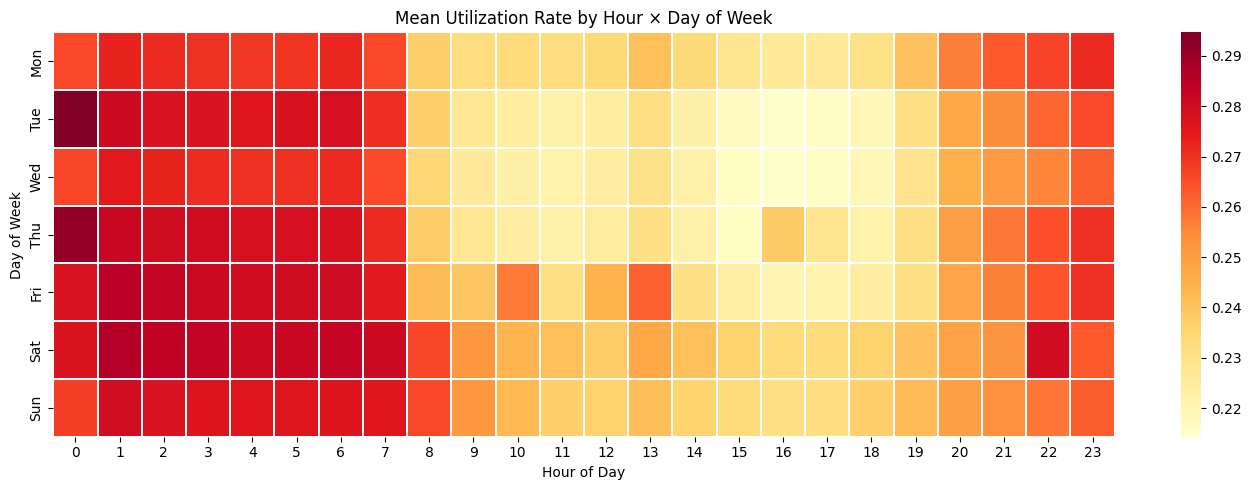

In [32]:
heatmap_data = occ_rate_flat.groupby(['dow', 'hour']).mean().mean(axis=1).unstack()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
)
ax.set_title('Mean Utilization Rate by Hour × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
#plt.savefig('demand_heatmap.png', dpi=150)
plt.show()

In [33]:
occ_mean = pd.DataFrame()
occ_mean['average_occupancy'] = data['occ'].iloc[:, 1:].mean(axis=1)
occ_mean['time'] = pd.to_datetime(data['occ']['time'])
occ_mean['hour'] = occ_mean['time'].dt.hour
occ_mean['dow'] = occ_mean['time'].dt.dayofweek
occ_mean['is_weekend'] = occ_mean['dow'].isin([5, 6]).astype(int)

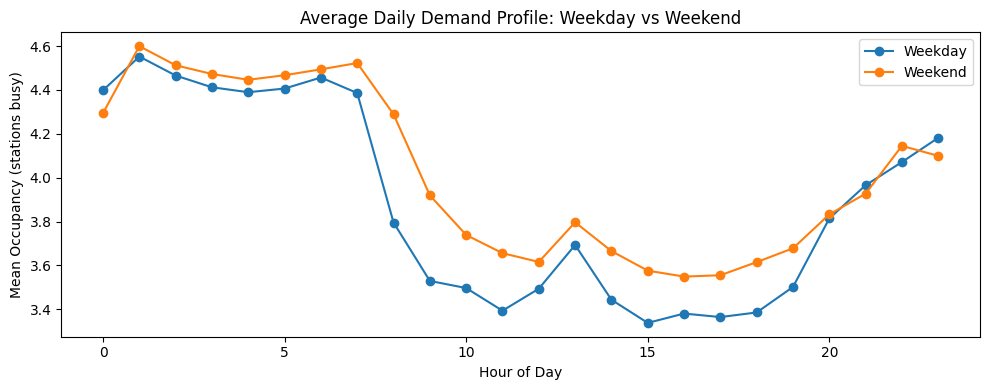

In [34]:
daily_profile = (
    occ_mean
    .groupby(['is_weekend', 'hour'])['average_occupancy']
    .mean()
    .unstack(0)
)

daily_profile.columns = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(10, 4))
daily_profile.plot(ax=ax, marker='o')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Occupancy (stations busy)')
ax.set_title('Average Daily Demand Profile: Weekday vs Weekend')

plt.tight_layout()
#plt.savefig('weekday_vs_weekend.png', dpi=150)
plt.show()

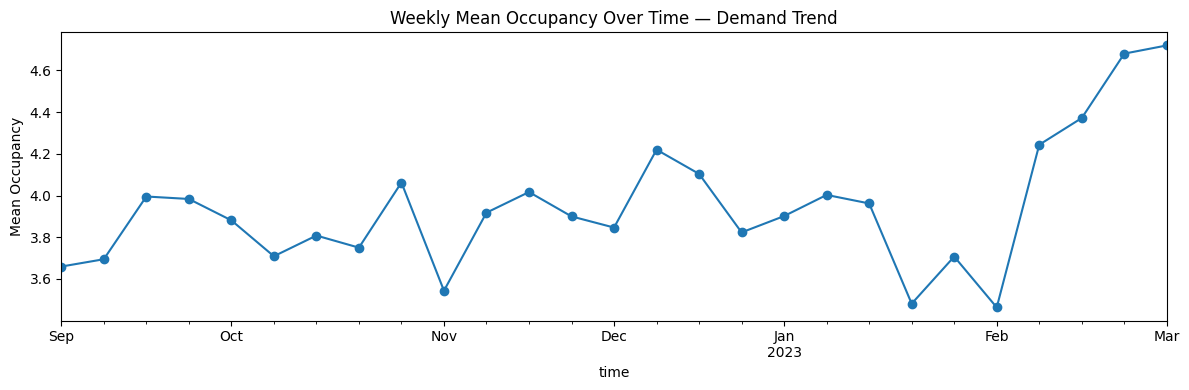

In [35]:
occ_weekly = data['occ'].copy()
occ_weekly['time'] = pd.to_datetime(occ_weekly['time'])
occ_weekly = occ_weekly.set_index('time')

weekly_mean = occ_weekly.mean(axis=1).resample('W').mean()
fig, ax = plt.subplots(figsize=(12, 4))
weekly_mean.plot(ax=ax, marker='o')

ax.set_title('Weekly Mean Occupancy Over Time — Demand Trend')
ax.set_ylabel('Mean Occupancy')

plt.tight_layout()
#plt.savefig('weekly_trend.png', dpi=150)
plt.show()

In [36]:
STATIONS=STATIONS[1:]

In [37]:
data['occ_rate'].isna().sum().sum()
data['occ_rate']['2125']=data['occ_rate']['2125'].fillna(0)

In [38]:
data['occ_rate'] = data['occ_rate'].astype({col: 'int' for col in data['occ_rate'].columns if col != 'time'})

In [39]:
summary = pd.DataFrame(index=STATIONS)
summary['mean_util'] = data['occ_rate'].iloc[:, 1:].mean()
summary['peak_util'] = data['occ_rate'].iloc[:, 1:].max()
summary['pct_saturated'] = (data['occ_rate'].iloc[:, 1:] > 0.8).mean()
summary['mean_duration'] = data['dur'].iloc[:, 1:].mean()
summary['mean_volume'] = data['vol'].iloc[:, 1:].mean()
summary['cv'] = data['occ'].iloc[:, 1:].std() / data['occ'].iloc[:, 1:].mean()
summary = summary.join(data['inf'][['latitude', 'longitude', 'pile_count']])

In [40]:
summary

,mean_util,peak_util,pct_saturated,mean_duration,mean_volume,cv,latitude,longitude,pile_count
1001,0.127532,1,0.127532,0.844153,5.909070,0.608704,22.714121,113.784724,20
1002,0.244705,1,0.244705,0.957815,6.704708,0.699909,22.725900,113.785002,22
1003,0.001151,1,0.001151,0.159626,1.117384,1.759824,22.735538,113.787971,6
1004,0.036372,1,0.036372,4.612262,108.257789,0.365776,22.693449,113.788126,11
1005,0.000000,0,0.000000,3.803714,86.900687,0.302234,22.693449,113.788126,11
...,...,...,...,...,...,...,...,...,...
2678,0.000000,0,0.000000,0.156231,1.093616,3.481585,22.596409,114.478137,13
2679,0.000921,1,0.000921,2.034895,14.244264,0.665840,22.601834,114.481163,12
2680,0.041436,1,0.041436,0.177601,1.243209,1.710433,22.509882,114.483345,12
2681,0.034070,1,0.034070,0.364545,2.551815,0.896049,22.533926,114.493513,10


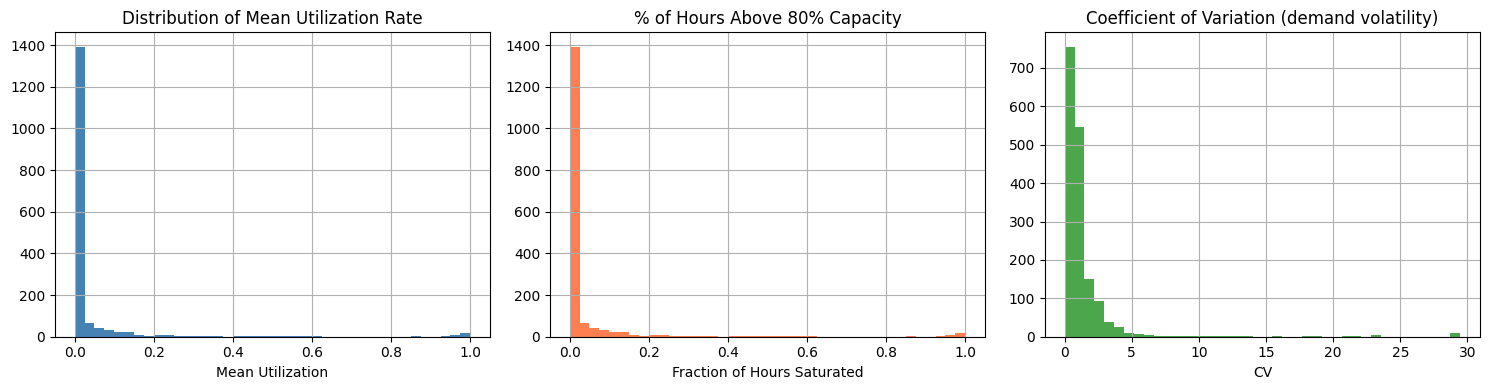

In [41]:
# --- Saturation risk distribution ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

summary['mean_util'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Mean Utilization Rate')
axes[0].set_xlabel('Mean Utilization')

summary['pct_saturated'].hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('% of Hours Above 80% Capacity')
axes[1].set_xlabel('Fraction of Hours Saturated')

summary['cv'].hist(bins=40, ax=axes[2], color='green', alpha=0.7)
axes[2].set_title('Coefficient of Variation (demand volatility)')
axes[2].set_xlabel('CV')

plt.tight_layout()
#plt.savefig('station_distributions.png', dpi=150)
plt.show()

In [42]:
high_risk = summary[summary['pct_saturated'] > 0.3].sort_values('pct_saturated', ascending=False)
print(f"\nHigh saturation stations (>30% of hours above 80% capacity): {len(high_risk)}")
print(high_risk[['mean_util', 'pct_saturated', 'pile_count']].head(15))


High saturation stations (>30% of hours above 80% capacity): 77
      mean_util  pct_saturated  pile_count
2668   1.000000       1.000000           1
2095   1.000000       1.000000           3
2138   1.000000       1.000000          37
2514   1.000000       1.000000           3
1334   1.000000       1.000000           4
1630   0.988720       0.988720           2
1518   0.988720       0.988720           2
1335   0.988720       0.988720           3
2412   0.988720       0.988720           3
2309   0.987799       0.987799           4
2611   0.984346       0.984346          40
2193   0.980433       0.980433          28
1072   0.980433       0.980433          14
1581   0.980433       0.980433          18
1265   0.980433       0.980433          45


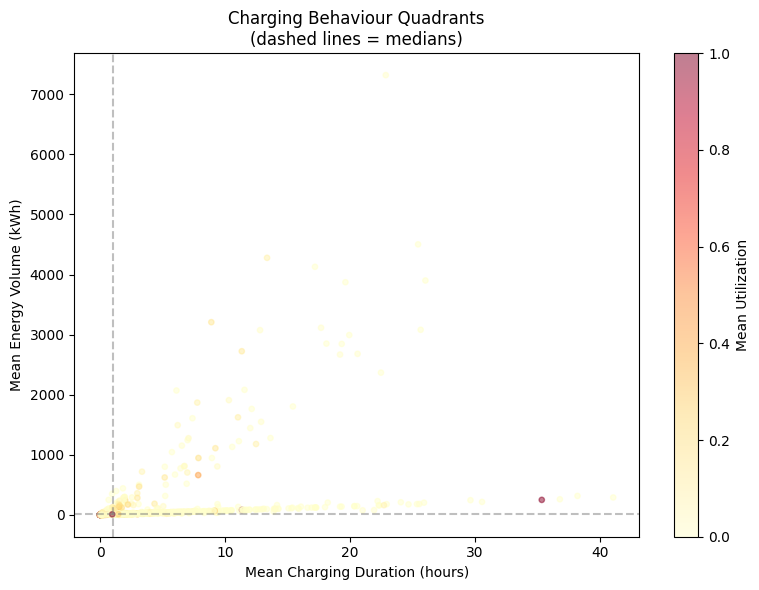

In [43]:
# --- Volume vs duration: charging behaviour quadrants ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    summary['mean_duration'],
    summary['mean_volume'],
    c=summary['mean_util'],
    cmap='YlOrRd',
    alpha=0.5,
    s=15
)
plt.colorbar(sc, ax=ax, label='Mean Utilization')
ax.axvline(summary['mean_duration'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(summary['mean_volume'].median(),   color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean Charging Duration (hours)')
ax.set_ylabel('Mean Energy Volume (kWh)')
ax.set_title('Charging Behaviour Quadrants\n(dashed lines = medians)')
plt.tight_layout()
#plt.savefig('charging_quadrants.png', dpi=150)
plt.show()

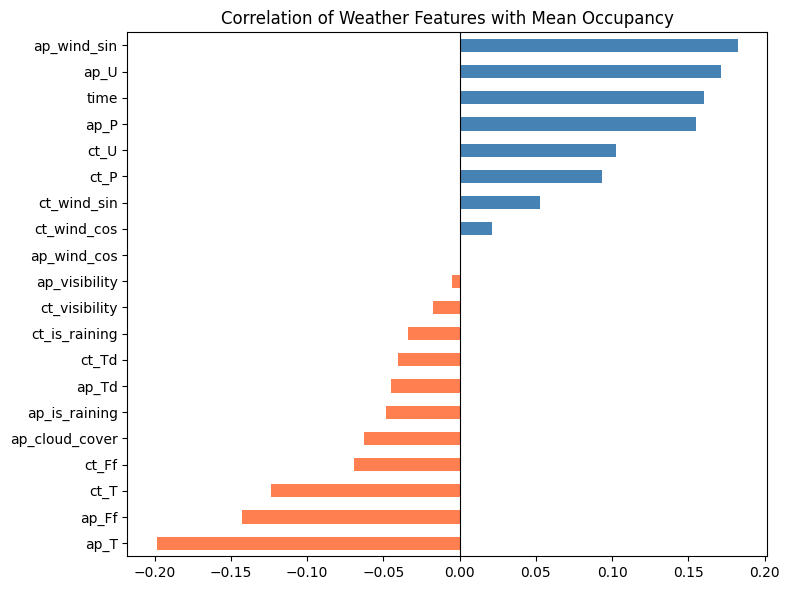

In [44]:
weather_occ = data['weather'].copy()
weather_occ['mean_occ'] = occ_mean['average_occupancy'].values

corr = weather_occ.corr()['mean_occ'].drop('mean_occ').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind='barh', ax=ax, color=['coral' if x < 0 else 'steelblue' for x in corr])
ax.set_title('Correlation of Weather Features with Mean Occupancy')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
#plt.savefig('weather_correlations.png', dpi=150)
plt.show()

In [45]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Timespan:         {TIMESTAMPS[0]} → {TIMESTAMPS[-1]}")
print(f"Stations:         {len(STATIONS)}")
print(f"Mean utilization: {summary['mean_util'].mean():.1%}")
print(f"High-risk stations (>30% sat): {len(high_risk)} ({len(high_risk)/len(STATIONS):.1%})")
print(f"Mean e_price:     {df_price['electric_price'].mean():.3f} Yuan/kWh")
print(f"Mean s_price:     {df_price['service_price'].mean():.3f} Yuan/kWh")

DATASET SUMMARY
Timespan:         0 → 4343
Stations:         1682
Mean utilization: 4.5%
High-risk stations (>30% sat): 77 (4.6%)
Mean e_price:     0.945 Yuan/kWh
Mean s_price:     0.738 Yuan/kWh


In [46]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

geolocator = Nominatim(user_agent="ev_charging_project")
reverse    = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_district(lat, lon):
    try:
        location = reverse((lat, lon), language='en')
        address  = location.raw.get('address', {})
        return (
            address.get('city_district') or
            address.get('suburb')        or
            address.get('county')        or
            address.get('district')      or
            'Unknown'
        )
    except Exception:
        return 'Unknown'

print("Reverse geocoding stations...")
inf['district'] = inf.apply(
    lambda row: get_district(row['latitude'], row['longitude']), axis=1
)

print(inf['district'].value_counts())
#inf.to_csv('inf_with_districts.csv', index=False)  

Reverse geocoding stations...
district
Longcheng Sub-district      99
Xixiang Sub-District        89
Yuehai Sub-district         80
Minzhi Sub-district         64
Futian Sub-district         58
                            ..
Qianhai Cooperation Zone     2
Nan'ao Sub-district          2
Unknown                      2
Xinhu Sub-district           1
Qiuchang                     1
Name: count, Length: 82, dtype: int64


In [47]:
district_mapping = {
    # Bao'an District
    'Shajing Sub-district': "Bao'an District", 'Fuhai Sub-district': "Bao'an District",
    'Fuyong Sub-district': "Bao'an District", 'Songgang Sub-District': "Bao'an District",
    'Xinqiao Sub-District': "Bao'an District", 'Hangcheng Sub-District': "Bao'an District",
    'Xixiang Sub-District': "Bao'an District", 'Yanluo Sub-District': "Bao'an District",
    "Xin'an Sub-District": "Bao'an District", 'Shiyan Sub-District': "Bao'an District",
    
    # Guangming District
    'Matian Sub-district': "Guangming District", 'Gongming Sub-district': "Guangming District",
    'Yutang Sub-District': "Guangming District", 'Fenghuang Sub-District': "Guangming District",
    'Xinhu Sub-district': "Guangming District", 'Guangming Sub-district': "Guangming District",
    
    # Nanshan District
    'Zhaoshang Sub-district': "Nanshan District", 'Nanshan Sub-district': "Nanshan District",
    'Qianhai Cooperation Zone': "Nanshan District", 'Nantou Sub-district': "Nanshan District",
    'Shekou Sub-district': "Nanshan District", 'Yuehai Sub-district': "Nanshan District",
    'Xili Sub-District': "Nanshan District", 'Taoyuan Sub-District': "Nanshan District",
    'Shahe': "Nanshan District",
    
    # Longhua District
    'Dalang Sub-District': "Longhua District", 'Fucheng Sub-District': "Longhua District",
    'Longhua Sub-District': "Longhua District", 'Minzhi Sub-district': "Longhua District",
    'Guanlan Sub-District': "Longhua District", 'Guanhu Sub-District': "Longhua District",
    
    # Futian District
    'Xiangmihu Sub-district': "Futian District", 'Shatou Sub-district': "Futian District",
    'Meilin Sub-district': "Futian District", 'Lianhua Sub-district': "Futian District",
    'Fubao Sub-district': "Futian District", 'Futian Sub-district': "Futian District",
    'Futian Bonded Area': "Futian District", 'Huafu Sub-district': "Futian District",
    'Nanyuan Sub-district': "Futian District", 'Huaqiangbei Sub-district': "Futian District",
    'Yuanling Sub-district': "Futian District",
    
    # Longgang District
    'Bantian Sub-District': "Longgang District", 'Jihua Sub-district': "Longgang District",
    'Pinghu Sub-district': "Longgang District", 'Buji Sub-district': "Longgang District",
    'Nanwan Sub-district': "Longgang District", 'Henggang Sub-district': "Longgang District",
    'Yuanshan Sub-district': "Longgang District", 'Longcheng Sub-district': "Longgang District",
    'Longgang Sub-district': "Longgang District", 'Baolong Sub-district': "Longgang District",
    'Pingde Sub-district': "Longgang District", 'Ma On Tong': "Longgang District",
    
    # Luohu District
    'Qingshuihe Sub-district': "Luohu District", 'Guiyuan Sub-district': "Luohu District",
    'Sungang Sub-district': "Luohu District", 'Nanhu Sub-district': "Luohu District",
    'Dongxiao Sub-district': "Luohu District", 'Dongmen Sub-district': "Luohu District",
    'Cuizhu Sub-district': "Luohu District", 'Huangbei Sub-district': "Luohu District",
    'Donghu Sub-district': "Luohu District", 'Liantang Sub-district': "Luohu District",
    
    # Yantian District
    'Haishan Sub-district': "Yantian District", 'Shatoujiao Sub-district': "Yantian District",
    'Yantian Sub-district': "Yantian District", 'Meisha Sub-district': "Yantian District",
    
    # Pingshan District
    'Biling Sub-district': "Pingshan District", 'Pingshan Sub-district': "Pingshan District",
    'Maluan Sub-district': "Pingshan District", 'Longtian Sub-district': "Pingshan District",
    'Shijing Sub-district': "Pingshan District", 'Kengzi Sub-district': "Pingshan District",
    
    # Dapeng New Area
    'Kuichong Sub-district': "Dapeng New Area", 'Dapeng Sub-district': "Dapeng New Area",
    "Nan'ao Sub-district": "Dapeng New Area",
    
    # Out of bounds / Unknown
    'Unknown': "Unknown",
    'Yuen Long District': "Hong Kong",
    'North District': "Hong Kong",
    'Man Kam To': "Hong Kong",
    'Qiuchang': "Huizhou"
}

inf['station_district'] = inf['district'].map(district_mapping)

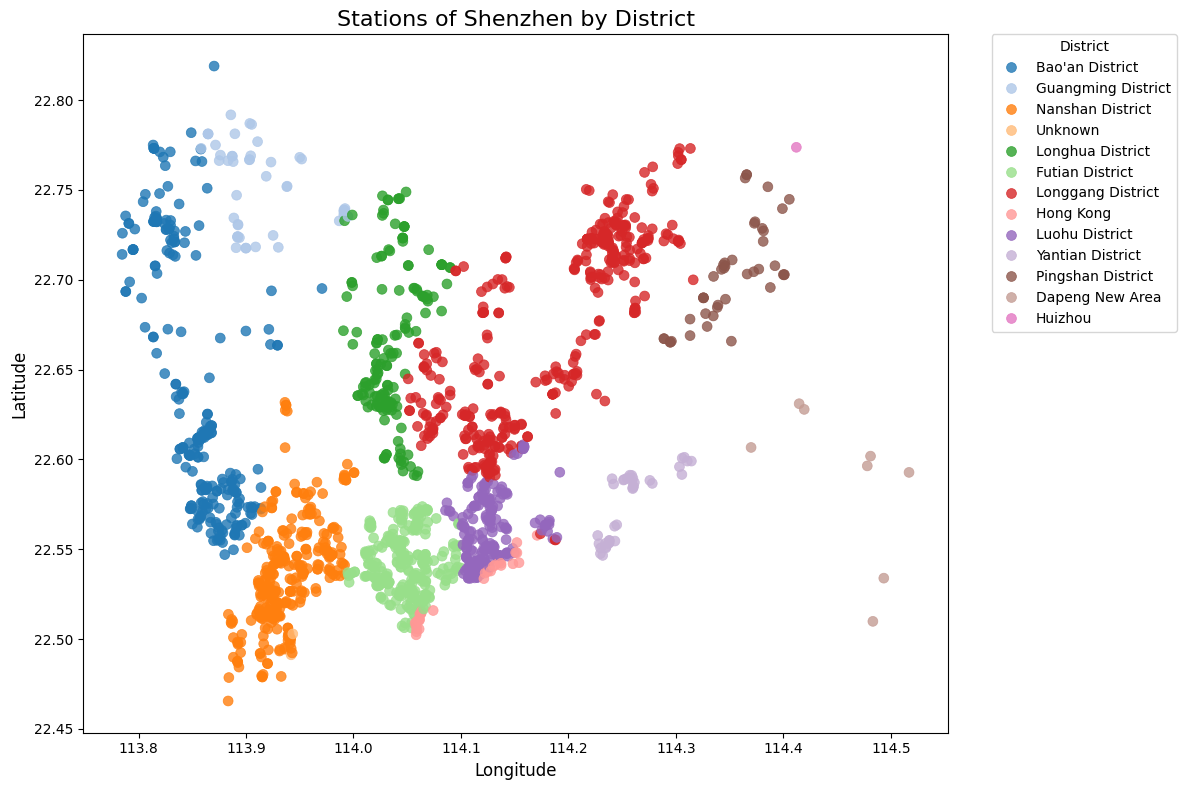

In [48]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=inf, 
    x='longitude', 
    y='latitude', 
    hue='station_district',      
    palette='tab20',     
    s=50,                
    alpha=0.8,          
    edgecolor=None
)

plt.title('Stations of Shenzhen by District', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='District')
plt.tight_layout()
#plt.savefig('shenzhen_districts_map.png', dpi=300)
plt.show()

### Station Clustering

In [49]:
# Use mean occupancy rate by hour-of-day × day-of-week as the profile
# Shape: (1682 stations, 168 features) — one per hour of the week
occ_rate = data['occ_rate'].copy()
occ_rate['time'] = pd.to_datetime(occ_rate['time'])
occ_rate['dow']  = occ_rate['time'].dt.dayofweek
occ_rate['hour'] = occ_rate['time'].dt.hour

station_cols = [col for col in occ_rate.columns if col not in ['time', 'dow', 'hour']]
# Average occupancy rate for each (dow, hour) combination per station
profiles = (
    occ_rate
    .groupby(['dow', 'hour'])[station_cols]
    .mean()
    .T
)

# Drop any stations with NaN profiles
profiles = profiles.dropna()
print(f"Clustering {len(profiles)} stations over {profiles.shape[1]} time features")

# Normalize — important so high-capacity stations don't dominate
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(profiles)

Clustering 1682 stations over 168 time features


In [50]:
profiles

dow          0                                                              \
hour        0         1         2         3         4         5         6    
1001  0.192308  0.076923  0.115385  0.153846  0.038462  0.115385  0.076923   
1002  0.461538  0.269231  0.307692  0.230769  0.230769  0.192308  0.269231   
1003  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1004  0.000000  0.076923  0.038462  0.038462  0.038462  0.038462  0.038462   
1005  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
...        ...       ...       ...       ...       ...       ...       ...   
2678  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2679  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2680  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462   
2681  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462   
2682  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

dow                                 ...         6                      \
hour        7         8         9   ...        14        15        16   
1001  0.076923  0.153846  0.230769  ...  0.115385  0.230769  0.192308   
1002  0.230769  0.307692  0.269231  ...  0.230769  0.269231  0.192308   
1003  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
1004  0.000000  0.038462  0.038462  ...  0.000000  0.000000  0.000000   
1005  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
...        ...       ...       ...  ...       ...       ...       ...   
2678  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
2679  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
2680  0.038462  0.038462  0.038462  ...  0.038462  0.038462  0.038462   
2681  0.038462  0.038462  0.038462  ...  0.038462  0.038462  0.038462   
2682  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   

dow                                                                         
hour        17        18        19        20        21        22        23  
1001  0.230769  0.153846  0.153846  0.115385  0.115385  0.076923  0.076923  
1002  0.153846  0.230769  0.230769  0.153846  0.192308  0.269231  0.230769  
1003  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
1004  0.000000  0.000000  0.000000  0.076923  0.038462  0.076923  0.038462  
1005  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
...        ...       ...       ...       ...       ...       ...       ...  
2678  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
2679  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
2680  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  
2681  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  0.038462  
2682  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  

[1682 rows x 168 columns]

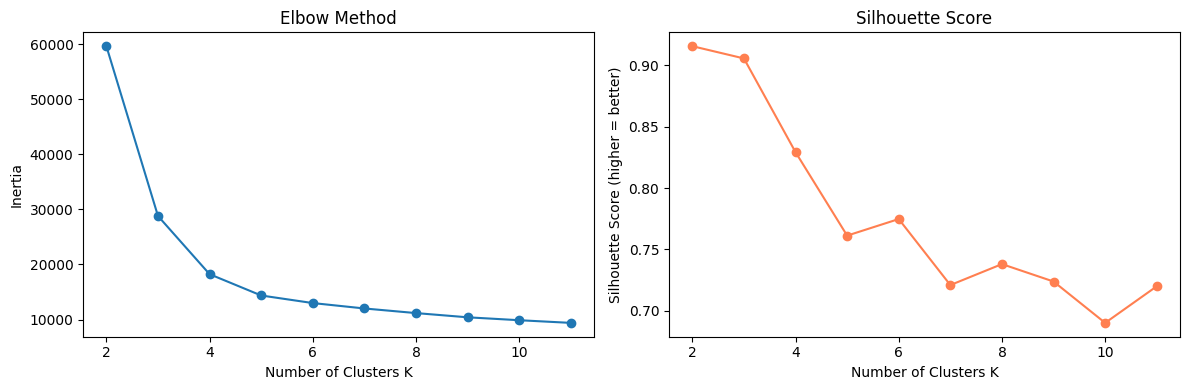

In [51]:
inertias    = []
silhouettes = []
K_range     = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=500))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
#plt.savefig('cluster_selection.png', dpi=150)
plt.show()

In [52]:
K = 4  # adjust based on elbow/silhouette plots

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

# Add cluster assignment to summary and inf
profiles['cluster'] = cluster_labels
summary['cluster']  = profiles['cluster']
data['inf']['cluster'] = profiles['cluster']

print(summary['cluster'].value_counts().sort_index())

cluster
0    1496
1      32
2      45
3     109
Name: count, dtype: int64


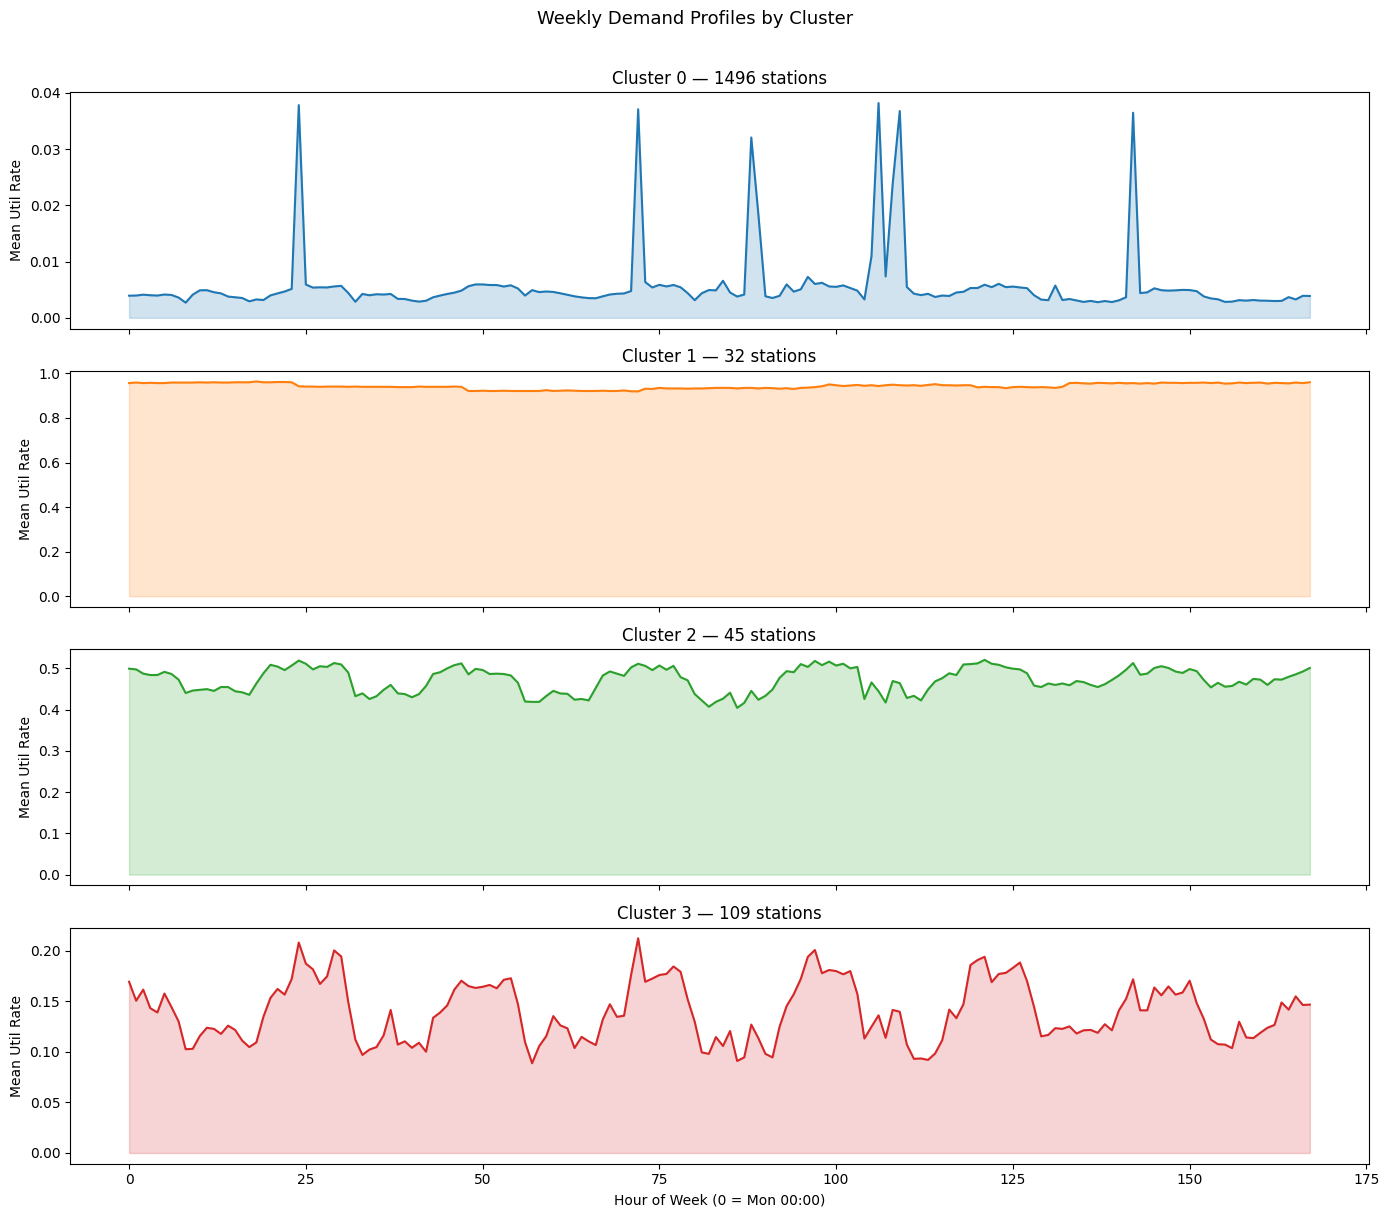

In [53]:
fig, axes = plt.subplots(K, 1, figsize=(14, 3 * K), sharex=True)
hours = range(168)

for k in range(K):
    cluster_stations = profiles[profiles['cluster'] == k].index
    cluster_mean = profiles.loc[cluster_stations].drop(columns='cluster').mean()
    axes[k].plot(cluster_mean.values, color=f'C{k}')
    axes[k].fill_between(hours, cluster_mean.values, alpha=0.2, color=f'C{k}')
    axes[k].set_title(f'Cluster {k} — {len(cluster_stations)} stations')
    axes[k].set_ylabel('Mean Util Rate')

axes[-1].set_xlabel('Hour of Week (0 = Mon 00:00)')
plt.suptitle('Weekly Demand Profiles by Cluster', y=1.01, fontsize=13)
plt.tight_layout()
#plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

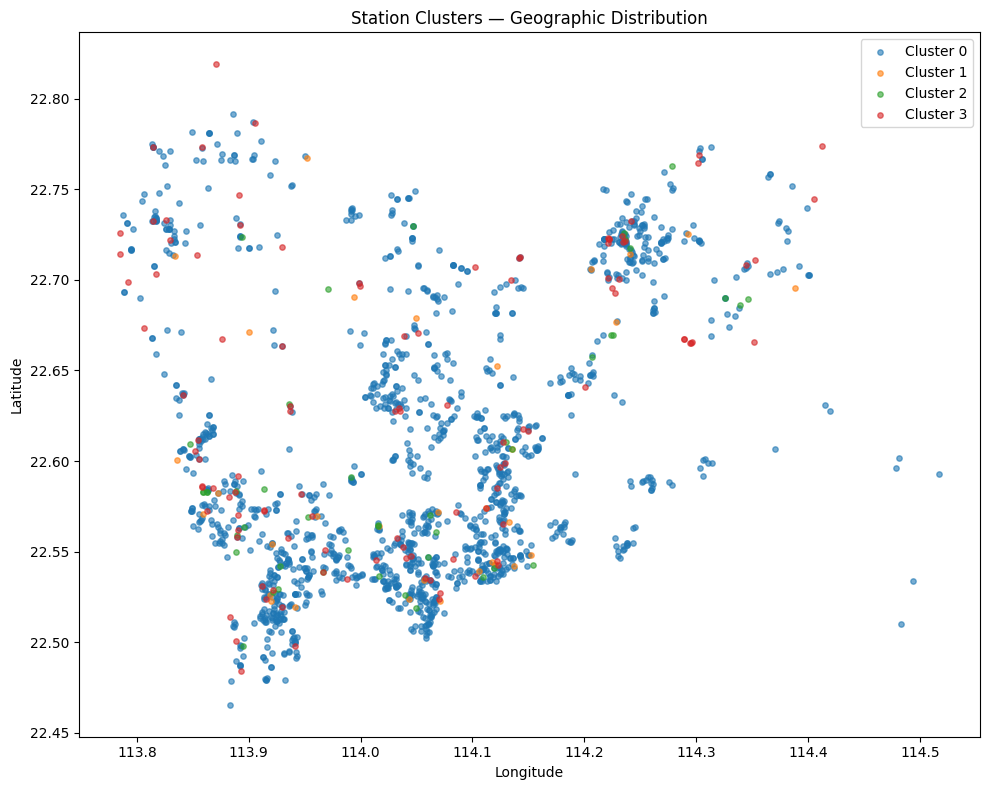

In [54]:
colors = [f'C{k}' for k in summary['cluster']]

fig, ax = plt.subplots(figsize=(10, 8))
for k in range(K):
    mask = summary['cluster'] == k
    ax.scatter(
        summary.loc[mask, 'longitude'],
        summary.loc[mask, 'latitude'],
        label=f'Cluster {k}',
        s=15, alpha=0.6
    )
ax.set_title('Station Clusters — Geographic Distribution')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
#plt.savefig('cluster_map.png', dpi=150)
plt.show()

### Aggregation + Baselines

In [55]:
system = pd.DataFrame()
system['time'] = df_occ['time']
system['occ_rate'] = data['occ_rate'].iloc[:, 1:].mean(axis=1)
system['occ_raw'] = data['occ'].iloc[:, 1:].mean(axis=1)
system['vol'] = data['vol'].iloc[:, 1:].mean(axis=1)
system['dur'] = data['dur'].iloc[:, 1:].mean(axis=1)
system['ep'] = data['ep'].iloc[:, 1:].mean(axis=1)
system['sp'] = data['sp'].iloc[:, 1:].mean(axis=1)
system['total_price'] = system['ep'] + system['sp']

data['weather'] = data['weather'].drop(['time'],axis=1)
system = system.join(data['weather'])

print(system.shape)
print(system.isnull().sum())

(4344, 27)
time              0
occ_rate          0
occ_raw           0
vol               0
dur               0
ep                0
sp                0
total_price       0
ap_T              0
ap_P              0
ap_U              0
ap_Ff             0
ap_Td             0
ap_wind_sin       0
ap_wind_cos       0
ap_is_raining     0
ap_cloud_cover    0
ap_visibility     0
ct_T              0
ct_P              0
ct_U              0
ct_Ff             0
ct_Td             0
ct_wind_sin       0
ct_wind_cos       0
ct_is_raining     0
ct_visibility     0
dtype: int64


In [56]:
def build_system_features(df):
    df = df.copy()

    # --- Temporal ---
    df['time']=pd.to_datetime(df['time'])
    df['hour']       = df['time'].dt.hour
    df['dow']        = df['time'].dt.dayofweek
    df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
    df['month']      = df['time'].dt.month
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']    = np.sin(2 * np.pi * df['dow'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dow'] / 7)

    # --- Occupancy lags & rolling stats ---
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f'occ_lag_{lag}h'] = df['occ_rate'].shift(lag)
    for window in [3, 6, 24, 168]:
        df[f'occ_roll_mean_{window}h'] = df['occ_rate'].shift(1).rolling(window).mean()
        df[f'occ_roll_std_{window}h']  = df['occ_rate'].shift(1).rolling(window).std()

    # --- Volume ---
    for lag in [1, 24]:
        df[f'vol_lag_{lag}h'] = df['vol'].shift(lag)
    df['vol_roll_mean_24h'] = df['vol'].shift(1).rolling(24).mean()

    # --- Duration ---
    for lag in [1, 24]:
        df[f'dur_lag_{lag}h'] = df['dur'].shift(lag)
    df['dur_roll_mean_24h'] = df['dur'].shift(1).rolling(24).mean()

    # --- Price ---
    df['ep_lag_1h']            = df['ep'].shift(1)
    df['ep_roll_mean_24h']     = df['ep'].shift(1).rolling(24).mean()
    df['sp_lag_1h']            = df['sp'].shift(1)
    df['sp_roll_mean_24h']     = df['sp'].shift(1).rolling(24).mean()
    df['total_price_lag_1h']   = df['total_price'].shift(1)

    df = df.dropna()
    return df

system_df = build_system_features(system)
system_df = system_df.drop(["time"],axis=1)
print(f"System feature matrix: {system_df.shape}")
print(f"Features: {system_df.columns.tolist()}")

System feature matrix: (4176, 61)
Features: ['occ_rate', 'occ_raw', 'vol', 'dur', 'ep', 'sp', 'total_price', 'ap_T', 'ap_P', 'ap_U', 'ap_Ff', 'ap_Td', 'ap_wind_sin', 'ap_wind_cos', 'ap_is_raining', 'ap_cloud_cover', 'ap_visibility', 'ct_T', 'ct_P', 'ct_U', 'ct_Ff', 'ct_Td', 'ct_wind_sin', 'ct_wind_cos', 'ct_is_raining', 'ct_visibility', 'hour', 'dow', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'occ_lag_1h', 'occ_lag_2h', 'occ_lag_3h', 'occ_lag_6h', 'occ_lag_12h', 'occ_lag_24h', 'occ_lag_48h', 'occ_lag_168h', 'occ_roll_mean_3h', 'occ_roll_std_3h', 'occ_roll_mean_6h', 'occ_roll_std_6h', 'occ_roll_mean_24h', 'occ_roll_std_24h', 'occ_roll_mean_168h', 'occ_roll_std_168h', 'vol_lag_1h', 'vol_lag_24h', 'vol_roll_mean_24h', 'dur_lag_1h', 'dur_lag_24h', 'dur_roll_mean_24h', 'ep_lag_1h', 'ep_roll_mean_24h', 'sp_lag_1h', 'sp_roll_mean_24h', 'total_price_lag_1h']


In [57]:
def time_split(df, val_frac=0.15, test_frac=0.15):
    n          = len(df)
    val_start  = int(n * (1 - val_frac - test_frac))
    test_start = int(n * (1 - test_frac))

    train = df.iloc[:val_start]
    val   = df.iloc[val_start:test_start]
    test  = df.iloc[test_start:]

    print(f"Train: {train.index[0]} → {train.index[-1]}  ({len(train)} rows)")
    print(f"Val:   {val.index[0]}   → {val.index[-1]}    ({len(val)} rows)")
    print(f"Test:  {test.index[0]}  → {test.index[-1]}   ({len(test)} rows)")
    return train, val, test

train, val, test = time_split(system_df)

Train: 168 → 3090  (2923 rows)
Val:   3091   → 3716    (626 rows)
Test:  3717  → 4343   (627 rows)


In [61]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [62]:
# --- Persistence: next hour = current hour ---
persistence_mae  = mean_absolute_error(test['occ_rate'], test['occ_lag_1h'])
persistence_rmse = np.sqrt(mean_squared_error(test['occ_rate'], test['occ_lag_1h']))
persistence_mape = mape(test['occ_rate'].values, test['occ_lag_1h'].values)
print(f"Persistence  → MAE={persistence_mae:.4f}  RMSE={persistence_rmse:.4f}  MAPE={persistence_mape:.2f}%")

# --- Seasonal naive: same hour last week ---
seasonal_mae  = mean_absolute_error(test['occ_rate'], test['occ_lag_168h'])
seasonal_rmse = np.sqrt(mean_squared_error(test['occ_rate'], test['occ_lag_168h']))
seasonal_mape = mape(test['occ_rate'].values, test['occ_lag_168h'].values)
print(f"Seasonal Naive → MAE={seasonal_mae:.4f}  RMSE={seasonal_rmse:.4f}  MAPE={seasonal_mape:.2f}%")

baseline_results = {
    'Persistence':    {'mae': persistence_mae,  'rmse': persistence_rmse,  'mape': persistence_mape},
    'Seasonal Naive': {'mae': seasonal_mae,      'rmse': seasonal_rmse,      'mape': seasonal_mape},
}

Persistence  → MAE=0.0012  RMSE=0.0019  MAPE=2.32%
Seasonal Naive → MAE=0.0074  RMSE=0.0095  MAPE=15.57%


In [63]:
y_train = train['occ_rate']
y_val = val['occ_rate']
y_test = test['occ_rate']

print("Fitting SARIMA...")
sarima_model = pm.auto_arima(
    y_train,
    seasonal=True,
    m=24,                       # daily seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=2, max_q=2,
    max_P=1, max_Q=1,
    max_d=1, max_D=1,
    information_criterion='aic',
)

print(sarima_model.summary())

# Forecast over test period
sarima_preds = sarima_model.predict(n_periods=len(y_test))
sarima_preds = np.clip(sarima_preds, 0, 1)  # occ_rate is bounded 0-1

sarima_mae  = mean_absolute_error(y_test, sarima_preds)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_preds))
sarima_mape = mape(y_test.values, sarima_preds)
print(f"SARIMA → MAE={sarima_mae:.4f}  RMSE={sarima_rmse:.4f}  MAPE={sarima_mape:.2f}%")

Fitting SARIMA...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2923
Model:               SARIMAX(2, 1, 1)   Log Likelihood                5539.843
Date:                Mon, 04 May 2026   AIC                         -11071.687
Time:                        12:02:19   BIC                         -11047.767
Sample:                             0   HQIC                        -11063.071
                               - 2923                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1052      0.008     13.184      0.000       0.090       0.121
ar.L2          0.0641      0.008      8.130      0.000       0.049       0.080
ma.L1         -0.9826      0.002  

C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\anyak\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [64]:
scaler  = MinMaxScaler()
train_s = pd.DataFrame(scaler.fit_transform(train), columns=train.columns, index=train.index)
val_s   = pd.DataFrame(scaler.transform(val),       columns=val.columns,   index=val.index)
test_s  = pd.DataFrame(scaler.transform(test),      columns=test.columns,  index=test.index)

for name, df in [('train', train_s), ('val', val_s), ('test', test_s)]:
    print(f"{name} NaNs: {df.isna().sum().sum()}")

train NaNs: 0
val NaNs: 0
test NaNs: 0


### LSTM

In [65]:
SEQ_LEN = 72
HORIZON = 24
BATCH = 32
EPOCHS = 50
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

class EVDataset(Dataset):
    def __init__(self, df, seq_len, horizon, target_col='occ_rate'):
        self.seq_len    = seq_len
        self.horizon    = horizon
        self.target_idx = df.columns.get_loc(target_col)
        self.X          = df.values.astype(np.float32)

    def __len__(self):
        return len(self.X) - self.seq_len - self.horizon + 1

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.seq_len]
        y = self.X[idx + self.seq_len : idx + self.seq_len + self.horizon, self.target_idx]
        return torch.tensor(x), torch.tensor(y)

train_loader = DataLoader(EVDataset(train_s, SEQ_LEN, HORIZON), batch_size=BATCH, shuffle=False)
val_loader = DataLoader(EVDataset(val_s,   SEQ_LEN, HORIZON), batch_size=BATCH, shuffle=False)
test_loader = DataLoader(EVDataset(test_s,  SEQ_LEN, HORIZON), batch_size=BATCH, shuffle=False)

Using device: cpu


In [66]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, 
                 horizon=HORIZON, dropout=0.2, activation='relu'):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            get_activation(activation),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, horizon)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

In [67]:
class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, horizon=HORIZON, dropout=0.1,
                 activation='relu'):
        super().__init__()
        self.input_proj    = nn.Linear(input_size, d_model)
        self.pos_embedding = nn.Embedding(SEQ_LEN, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='relu'  # internal transformer activation
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            get_activation(activation),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon)
        )

    def forward(self, x):
        B, T, _ = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        x = self.input_proj(x) + self.pos_embedding(positions)
        x = self.transformer(x)
        return self.head(x[:, -1, :])

In [68]:
def get_activation(name):
    """Return activation layer by name."""
    activations = {
        'relu':     nn.ReLU(),
        'gelu':     nn.GELU(),        
        'silu':     nn.SiLU(),       
        'tanh':     nn.Tanh(),
        'leakyrelu': nn.LeakyReLU(0.1),
        'elu':      nn.ELU(),
    }
    if name not in activations:
        raise ValueError(f"Unknown activation '{name}'. Choose from {list(activations.keys())}")
    return activations[name]

In [69]:
def evaluate_model(model, test_loader, scaler, target_col_idx=0):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch.to(DEVICE)).cpu().numpy()
            all_preds.append(pred)
            all_true.append(y_batch.numpy())

    preds = np.concatenate(all_preds, axis=0)  # (n_samples, horizon)
    trues = np.concatenate(all_true,  axis=0)

    # Inverse transform — only the target column
    # We need to reconstruct full-width arrays to use scaler.inverse_transform
    def inv_transform_target(arr):
        n_features = scaler.n_features_in_
        dummy = np.zeros((arr.shape[0] * arr.shape[1], n_features))
        dummy[:, target_col_idx] = arr.flatten()
        inv = scaler.inverse_transform(dummy)[:, target_col_idx]
        return inv.reshape(arr.shape)

    preds_inv = inv_transform_target(preds)
    trues_inv = inv_transform_target(trues)

    mae  = mean_absolute_error(trues_inv.flatten(), preds_inv.flatten())
    rmse = np.sqrt(mean_squared_error(trues_inv.flatten(), preds_inv.flatten()))
    mape_val = mape(trues_inv.flatten(), preds_inv.flatten())

    return preds_inv, trues_inv, {'mae': mae, 'rmse': rmse, 'mape': mape_val}

In [76]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def run_trial(model, train_loader, val_loader, lr, epochs=15, patience=3):
    """Lightweight training run for a single trial — fewer epochs than final training."""
    model     = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.MSELoss()

    best_val = float('inf')
    patience_ctr = 0

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_loss += criterion(
                    model(X_batch.to(DEVICE)), y_batch.to(DEVICE)
                ).item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val     = val_loss
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    return best_val

def lstm_objective(trial):
    params = {
        'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
        'num_layers':  trial.suggest_int('num_layers', 1, 3),
        'dropout':     trial.suggest_float('dropout', 0.1, 0.4),
        'lr':          trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'activation':  trial.suggest_categorical('activation', 
                           ['relu', 'gelu', 'silu', 'leakyrelu', 'elu']),
    }
    model = LSTMForecaster(
        input_size=n_features,
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout=params['dropout'],
        activation=params['activation']
    )
    return run_trial(model, train_loader, val_loader, lr=params['lr'])


# --- Transformer Objective ---
def transformer_objective(trial):
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    params  = {
        'd_model':         d_model,
        'nhead':           trial.suggest_categorical('nhead', 
                               [h for h in [2, 4, 8] if d_model % h == 0]),
        'num_layers':      trial.suggest_int('num_layers', 1, 4),
        'dim_feedforward': trial.suggest_categorical('dim_feedforward', [64, 128, 256]),
        'dropout':         trial.suggest_float('dropout', 0.05, 0.3),
        'lr':              trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'activation':      trial.suggest_categorical('activation',
                               ['relu', 'gelu', 'silu', 'leakyrelu', 'elu']),
    }
    model = TransformerForecaster(
        input_size=n_features,
        d_model=params['d_model'],
        nhead=params['nhead'],
        num_layers=params['num_layers'],
        dim_feedforward=params['dim_feedforward'],
        dropout=params['dropout'],
        activation=params['activation']
    )
    return run_trial(model, train_loader, val_loader, lr=params['lr'])

In [77]:
n_features = system_df.shape[1]
print("Tuning LSTM...")
lstm_study = optuna.create_study(direction='minimize')
lstm_study.optimize(lstm_objective, n_trials=10, show_progress_bar=True)

print("Tuning Transformer...")
tf_study = optuna.create_study(direction='minimize')
tf_study.optimize(transformer_objective, n_trials=10, show_progress_bar=True)

print("\n=== Best LSTM Params ===")
print(lstm_study.best_params)
print(f"Best val loss: {lstm_study.best_value:.6f}")

print("\n=== Best Transformer Params ===")
print(tf_study.best_params)
print(f"Best val loss: {tf_study.best_value:.6f}")

Tuning LSTM...


  0%|          | 0/10 [00:00<?, ?it/s]

Tuning Transformer...


  0%|          | 0/10 [00:00<?, ?it/s]


=== Best LSTM Params ===
{'hidden_size': 256, 'num_layers': 3, 'dropout': 0.21129666094969055, 'lr': 0.000774276282739938, 'activation': 'relu'}
Best val loss: 0.000054

=== Best Transformer Params ===
{'d_model': 128, 'nhead': 4, 'num_layers': 4, 'dim_feedforward': 256, 'dropout': 0.24098858487909663, 'lr': 0.0016580255259223324, 'activation': 'gelu'}
Best val loss: 0.000052


In [78]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=7):
    model     = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_weights  = model.state_dict()
    patience_ctr  = 0
    history       = {'train': [], 'val': []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        # --- Validate ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                pred     = model(X_batch)
                val_loss += criterion(pred, y_batch).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        scheduler.step(val_loss)
        history['train'].append(train_loss)
        history['val'].append(val_loss)

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d} | train={train_loss:.5f} | val={val_loss:.5f}")

    model.load_state_dict(best_weights)
    return model, history

In [79]:
# --- Final LSTM ---
best_lstm_params = lstm_study.best_params
lstm_final = LSTMForecaster(
    input_size=n_features,
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout'],
    activation=best_lstm_params['activation']
)
lstm_final, lstm_hist = train_model(
    lstm_final, train_loader, val_loader,
    lr=best_lstm_params['lr'], epochs=EPOCHS
)
lstm_preds, lstm_trues, lstm_metrics = evaluate_model(lstm_final, test_loader, scaler)
print(f"Tuned LSTM → MAE={lstm_metrics['mae']:.4f}  RMSE={lstm_metrics['rmse']:.4f}  MAPE={lstm_metrics['mape']:.2f}%")
torch.save(lstm_final.state_dict(), 'lstm_tuned.pt')

# --- Final Transformer ---
best_tf_params = tf_study.best_params
tf_final = TransformerForecaster(
    input_size=n_features,
    d_model=best_tf_params['d_model'],
    nhead=best_tf_params['nhead'],
    num_layers=best_tf_params['num_layers'],
    dim_feedforward=best_tf_params['dim_feedforward'],
    dropout=best_tf_params['dropout'],
    activation=best_tf_params['activation']
)
tf_final, tf_hist = train_model(
    tf_final, train_loader, val_loader,
    lr=best_tf_params['lr'], epochs=EPOCHS
)
tf_preds, tf_trues, tf_metrics = evaluate_model(tf_final, test_loader, scaler)
print(f"Tuned Transformer → MAE={tf_metrics['mae']:.4f}  RMSE={tf_metrics['rmse']:.4f}  MAPE={tf_metrics['mape']:.2f}%")
torch.save(tf_final.state_dict(), 'transformer_tuned.pt')

  Epoch   5 | train=0.00196 | val=0.00006
  Epoch  10 | train=0.00197 | val=0.00005
  Epoch  15 | train=0.00196 | val=0.00005
  Early stopping at epoch 16
Tuned LSTM → MAE=0.0067  RMSE=0.0076  MAPE=12.27%
  Epoch   5 | train=0.00210 | val=0.00007
  Epoch  10 | train=0.00199 | val=0.00006
  Epoch  15 | train=0.00197 | val=0.00006
  Epoch  20 | train=0.00197 | val=0.00005
  Early stopping at epoch 24
Tuned Transformer → MAE=0.0076  RMSE=0.0086  MAPE=13.74%


In [ ]:
'''n_features = system_df.shape[1]
print(f"Input feature count: {n_features}")

# --- LSTM ---
print("\nTraining LSTM...")
lstm = LSTMForecaster(input_size=n_features)
lstm, lstm_hist = train_model(lstm, train_loader, val_loader)
lstm_preds, lstm_trues, lstm_metrics = evaluate_model(lstm, test_loader, scaler)
print(f"LSTM → MAE={lstm_metrics['mae']:.4f}  RMSE={lstm_metrics['rmse']:.4f}  MAPE={lstm_metrics['mape']:.2f}%")
torch.save(lstm.state_dict(), 'lstm_system.pt')

# --- Transformer ---
print("\nTraining Transformer...")
transformer = TransformerForecaster(input_size=n_features)
transformer, tf_hist = train_model(transformer, train_loader, val_loader)
tf_preds, tf_trues, tf_metrics = evaluate_model(transformer, test_loader, scaler)
print(f"Transformer → MAE={tf_metrics['mae']:.4f}  RMSE={tf_metrics['rmse']:.4f}  MAPE={tf_metrics['mape']:.2f}%")
torch.save(transformer.state_dict(), 'transformer_system.pt')'''

In [80]:
# --- Full comparison table ---
all_results = {
    'Persistence':    baseline_results['Persistence'],
    'Seasonal Naive': baseline_results['Seasonal Naive'],
    'SARIMA':         {'mae': sarima_mae, 'rmse': sarima_rmse, 'mape': sarima_mape},
    'LSTM':           lstm_metrics,
    'Transformer':    tf_metrics,
}

comparison = pd.DataFrame(all_results).T
comparison.index.name = 'Model'
print("\n=== Final Model Comparison ===")
print(comparison.round(4))


=== Final Model Comparison ===
                   mae    rmse     mape
Model                                  
Persistence     0.0012  0.0019   2.3239
Seasonal Naive  0.0074  0.0095  15.5710
SARIMA          0.0063  0.0074  12.9014
LSTM            0.0067  0.0076  12.2685
Transformer     0.0076  0.0086  13.7382


C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\317272507.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(lstm_study)
C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\317272507.py:7: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(tf_study)


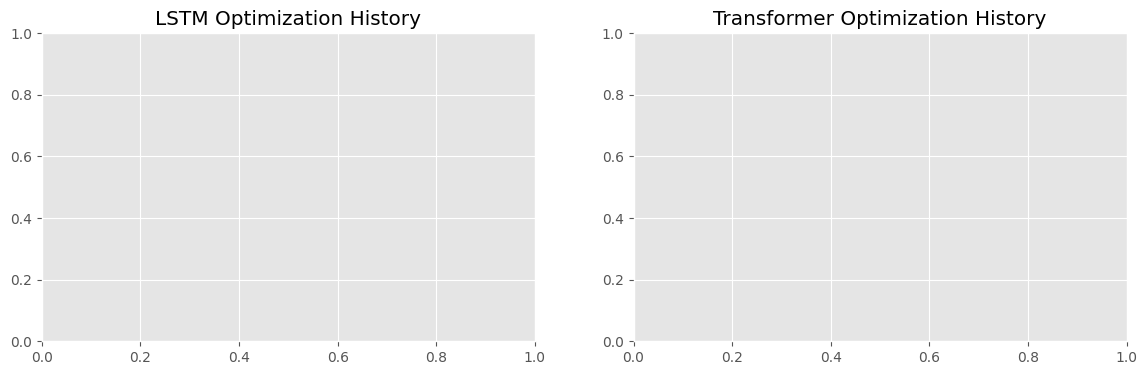

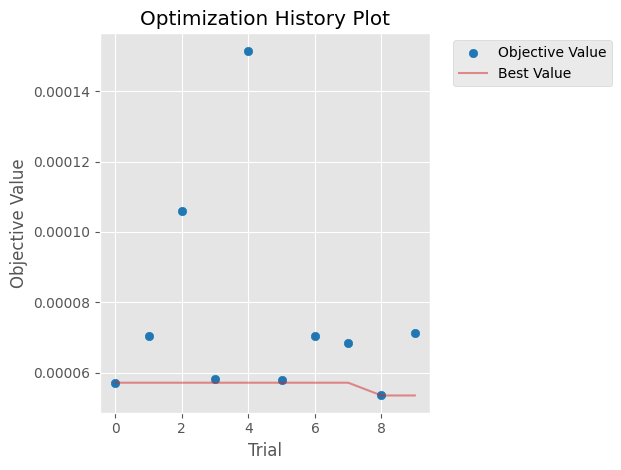

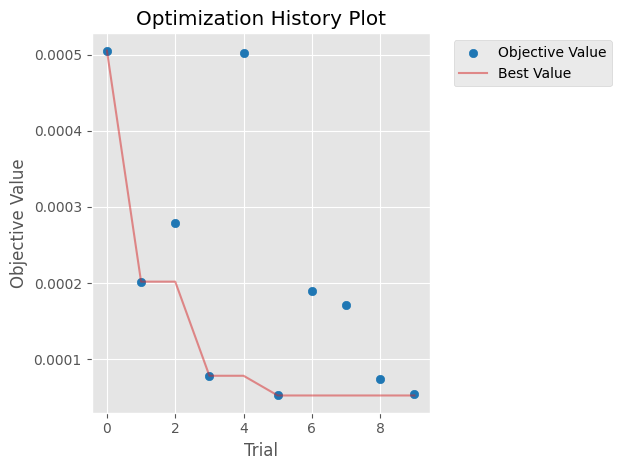

C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\317272507.py:17: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(lstm_study)
C:\Users\anyak\AppData\Local\Temp\ipykernel_14536\317272507.py:20: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(tf_study)


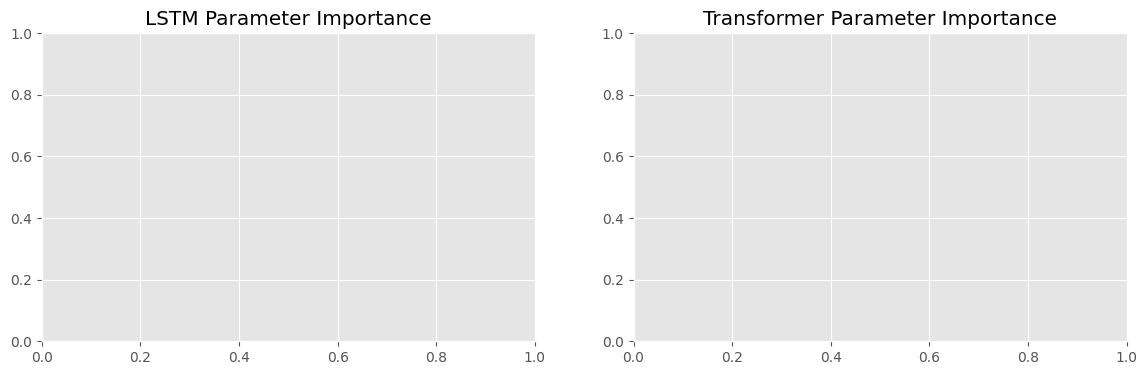

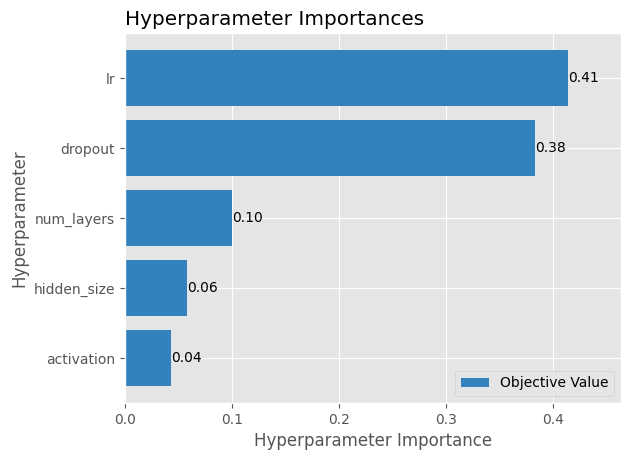

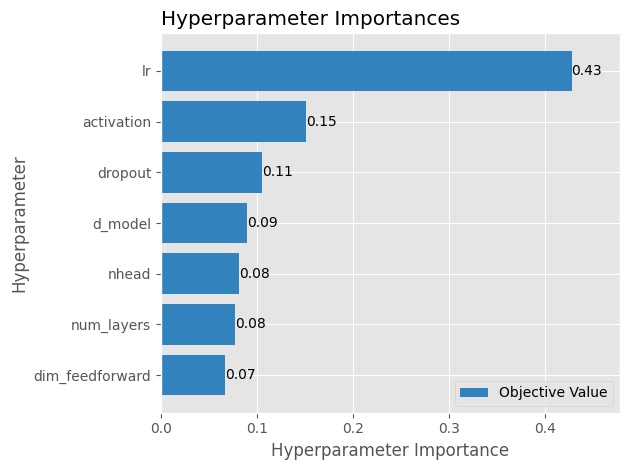


=== Final Model Comparison ===
                        mae    rmse     mape
Model                                       
Persistence          0.0012  0.0019   2.3239
Seasonal Naive       0.0074  0.0095  15.5710
SARIMA               0.0063  0.0074  12.9014
LSTM (tuned)         0.0067  0.0076  12.2685
Transformer (tuned)  0.0076  0.0086  13.7382


In [83]:
# --- Optimization history ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

optuna.visualization.matplotlib.plot_optimization_history(lstm_study)
axes[0].set_title('LSTM Optimization History')

optuna.visualization.matplotlib.plot_optimization_history(tf_study)
axes[1].set_title('Transformer Optimization History')

plt.tight_layout()
#plt.savefig('optuna_history.png', dpi=150)
plt.show()

# --- Parameter importance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

optuna.visualization.matplotlib.plot_param_importances(lstm_study)
axes[0].set_title('LSTM Parameter Importance')

optuna.visualization.matplotlib.plot_param_importances(tf_study)
axes[1].set_title('Transformer Parameter Importance')

plt.tight_layout()
#plt.savefig('optuna_importance.png', dpi=150)
plt.show()

# --- Final comparison including tuned models ---
all_results = {
    'Persistence':        baseline_results['Persistence'],
    'Seasonal Naive':     baseline_results['Seasonal Naive'],
    'SARIMA':             {'mae': sarima_mae, 'rmse': sarima_rmse, 'mape': sarima_mape},
    'LSTM (tuned)':       lstm_metrics,
    'Transformer (tuned)': tf_metrics,
}

comparison = pd.DataFrame(all_results).T
comparison.index.name = 'Model'
print("\n=== Final Model Comparison ===")
print(comparison.round(4))

In [85]:
print(lstm_study)